Title: Calculate_var_means.ipynb

Purpose: 

Author: Onno Nennecke on 14.05.2025 Modified: 14.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
import cftime

from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Importing functions
import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func
import Functions.wind_model_func as wind_model_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)

# Import alpha mask for rescaling wind speed
alpha_mask = xr.open_dataset('/home/onennecke/Capacity_data/alpha_land_sea.nc')

In [3]:
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask

In [4]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    
# Define a rough area for Germany
n = 55.5
s = 47
w = 5.5
e = 15.5

lon_edges = mask_offshore['lon'].values
lat_edges = mask_offshore['lat'].values

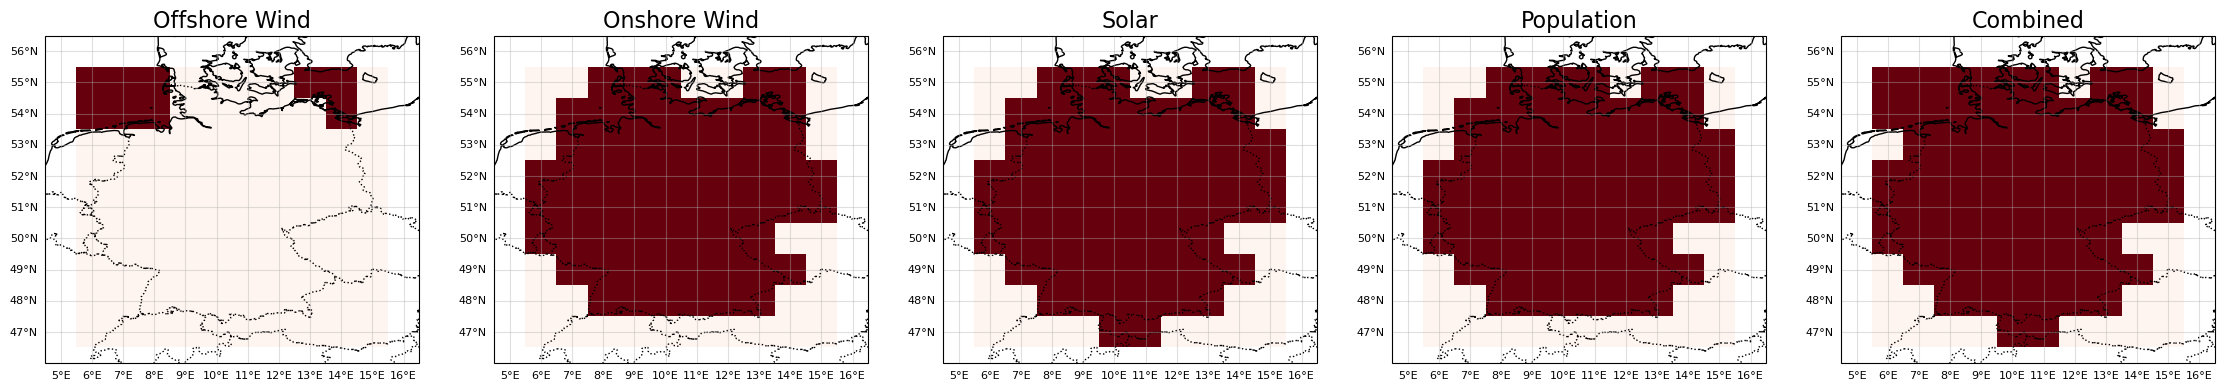

In [5]:
fig, axs = plt.subplots(1,5, figsize=(28, 8), subplot_kw={'projection': ccrs.PlateCarree()})
masks = [mask_offshore, mask_onshore, mask_solar, mask_population, overall_mask]
titles = ['Offshore Wind', 'Onshore Wind', 'Solar', 'Population', 'Combined']
for ax, m, titles in zip(axs.flat, masks, titles):
    ax.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree()) #[5, 16, 47, 56]
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    ax.set_title(f'{titles}', fontsize=16)
    
    # Plot the data
    im = ax.pcolormesh(lon_edges, lat_edges, m, transform=ccrs.PlateCarree(), cmap='Reds')
    
    # Add gridlines and colorbar
    setup_gridlines(ax)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()

### Calculate mean timeseries for ERA5

In [6]:
# Same for ERA5
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

# Read datasets for each variable
datasets_by_variable = {}
ds_list = []
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    ds = grid_func.regrid(ds, s = 47, n = 56, w = 5, e = 17)
    
    var_nm = list(ds.data_vars)[0]  # Get the variable name from the dataset
    
    ds = ds.rename({var_nm: var_names[var_nm]})
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    # Remove every 29.02
    ds_daily = ds_daily.where(~((ds['time.month'] == 2) & (ds['time.day'] == 29)), drop=True)
    ERA5_time = ds_daily['time']
    # datasets_by_variable[var] = ds_daily
    ds_list.append(ds_daily)
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'tas': 'tasmax'})
        tasmax = tasmax.where(~((ds['time.month'] == 2) & (ds['time.day'] == 29)), drop=True)
        ds_list.append(tasmax)
    

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

clim_ds['sfcWind'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
# clim_ds['tas'] = clim_ds['tas'] - 273.15
# clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

timeseries_ds = xr.Dataset()

# Calculate the mean for each variable
# timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist') # , country = 9.0, period = 'week'
# print('Load')
ts_output.load()
# print('Saving')
ts_output.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc')

# print('Finished saving')


In [7]:
ts_output

<xarray.Dataset> Size: 88kB
Dimensions:         (time: 3650)
Coordinates:
  * time            (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             <U4 16B 'hist'
    ESM             <U4 16B 'ERA5'
    ESM_run         <U9 36B 'ERA5_hist'
Data variables:
    sfcWind_masked  (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds_masked     (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas_masked      (time) float32 15kB 274.9 276.7 276.2 ... 273.4 274.7 274.3
    tasmax_masked   (time) float32 15kB 276.5 278.9 277.8 ... 275.6 275.8 276.5

### Define used models

In [8]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs
# Load climate data

MIP = 'ScenarioMIP' # CMIP
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'

In [9]:
# # Load climate data

# MIP = 'ScenarioMIP' # CMIP
# Institution = '*'
# # ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
# #            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# # ESMs = ['ACCESS-CM2'] # 'EC-Earth3-Veg'

# # ESMs = ['UKESM1-0-LL']
# # ESMs = ['TaiEMS1', 'UKESM1-0LL']
# scenario = 'ssp370'
# # run = 'r1i1p1f1'
# time_res = 'day'
# variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
# grid_def = '*'
# version = '*'


### Calculate mean timeseries per model

In [11]:
for i in range(len(used_runs)):
    ds_list = [] # List to hold individual datasets (one for each variable)

    run_time = time.time()
    ESM = used_runs['ESM'][i]
    Inst = used_runs['Institution'][i]
    run = used_runs['run'][i]
    output_file = f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc'
    if os.path.isfile( output_file ) == False:
        print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
        for var in variables:
            print(f'Processing variable: {var}')
            path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{run}_*'
            files = [f for f in glob.glob(path) if f.endswith('.nc')]

            nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            nc = nc[[var]]
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025))) # Filter years
            nc = grid_func.regrid(nc, s = 47, n = 56, w = 6, e = 16)  # Regrid the data
            
            nc = nc.drop_vars('height') if 'height' in nc.coords else nc
            
            if var == 'sfcWind':
                nc = wind_model_func._wind_scale(nc, 100, alpha_mask['mask'], 10)
            
            if isinstance(nc.time.values[0], cftime.Datetime360Day):
                print('Using 360-day calendar')
                # Duplicate the 30th of the month for these months
                extra_months = [4, 5, 6, 7, 8]

                # Duplicate the dataset for these time points
                duplicates = []
                for m in extra_months:
                    mask = (nc['time.month'] == m) & (nc['time.day'] == 30)
                    ds_dup = nc.sel(time=nc.time[mask])
                    duplicates.append(ds_dup)

                # Put everything together and sort by time
                nc = xr.concat([nc] + duplicates, dim='time').sortby('time')

                nc = nc.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
            elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
                print('Using no-leap calendar')
                nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            else:
                print('Using standard calendar')
                nc = nc.where(~((nc['time.month'] == 2) & (nc['time.day'] == 29)), drop=True)
                nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            # Append to list for later merging
            ds_list.append(nc)
        # Combine all into a single dataset
        combined_ds = xr.merge(ds_list)
        # if ds_list[2]['tas'].units == 'K':
        #     combined_ds['tas'] = combined_ds['tas'] - 273.15
        
        # if ds_list[3]['tasmax'].units == 'K':
        #     combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15
        timeseries_ds = xr.Dataset()
        # Calculate the mean for each variable
        # timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
    #     break
    # break

Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  2 m 10.3 s
Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  2 m 18.5 s
Processing Run Nr. 3, ACCESS-CM2, CSIRO-ARCCSS, r1i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  2 m 24.7 s
Processing Run Nr. 4, BCC-CSM2-MR, BCC, r1i1p1f1, 

Processing variable: sfcWind
Using no-leap calendar
Processing variable: rsds
Using no-lea

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Using no-leap calendar
Processing variable: rsds


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Using no-leap calendar
Processing variable: tas


...

Using no-leap calendar
Processing variable: rsds


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Using no-leap calendar
Processing variable: tas
Using no-leap calendar
Processing variable: tasmax


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Using no-leap calendar
Run time:  1 m 48.5 s
Processing Run Nr. 8, EC-Earth3, EC-Earth-Consortium, r149i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  3 m 15.4 s
Processing Run Nr. 9, EC-Earth3, EC-Earth-Consortium, r4i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  3 m 23.0 s
Processing Run Nr. 10, EC-Earth3, EC-Earth-Consortium, r148i1p1f1, 

Processing variable: sfcWind
Using standard calendar
Processing variable: rsds
Using standard calendar
Processing variable: tas
Using standard calendar
Processing variable: tasmax
Using standard calendar
Run time:  3 m 15.7 s
Processing Run Nr. 11, EC-Earth3, EC-Earth-Consortium, r105i1p1f1, 

Proce

----

In [43]:
path = '/climca/people/onennecke/model_output/var_means_masked/full_year/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
ts_datasets = ts_datasets.rename({
    'sfcWind_masked': 'sfcWind',
    'rsds_masked': 'rsds',
    'tas_masked': 'tas',
    'tasmax_masked': 'tasmax'
})

# Add day of year as a coordinate
# ts_datasets = ts_datasets.assign_coords(doy=np.tile(np.arange(1, 366), 10))
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

ts_datasets.load()

<xarray.Dataset> Size: 7MB
Dimensions:   (ESM_run: 100, time: 3650)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    country   float64 8B 9.0
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Data variables:
    sfcWind   (ESM_run, time) float64 3MB 8.056 6.177 6.451 ... 10.63 9.856
    rsds      (ESM_run, time) float32 1MB 13.75 24.11 38.15 ... 19.2 17.57 21.48
    tas       (ESM_run, time) float32 1MB 275.3 272.4 270.5 ... 279.4 277.5
    tasmax    (ESM_run, time) float32 1MB 277.2 273.9 272.2 ... 280.8 278.5

----

### Calculate Model Bias

In [44]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('doy').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'doy': mean_by_day['doy'].values,
        #### 'temp': mean_by_day['temp'].values,
        #### 'demand': mean_by_day['demand'].values,
        #### 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        #### 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        #### 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        #### 'solar_prod': mean_by_day['solar_prod'].values,
        #### 'total_prod': mean_by_day['total_prod'].values,
        #### 'netto': mean_by_day['Netto'].values,
        #### 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,doy,sfcWind,rsds,tas,tasmax,ESM
0,1,6.832429,23.096914,274.830353,276.532104,ACCESS-CM2
1,2,6.756827,23.791636,274.682465,276.377991,ACCESS-CM2
2,3,6.731797,26.174891,274.051300,275.734375,ACCESS-CM2
3,4,6.608799,27.544230,273.658417,275.408020,ACCESS-CM2
4,5,6.510941,28.201057,273.170929,274.980011,ACCESS-CM2
...,...,...,...,...,...,...
4010,361,5.974821,26.066833,273.956482,275.977997,UKESM1-0-LL
4011,362,6.066361,27.131372,273.843231,275.899292,UKESM1-0-LL
4012,363,6.123416,26.580833,273.823853,275.899231,UKESM1-0-LL
4013,364,6.049092,26.170652,273.884979,275.871338,UKESM1-0-LL


In [46]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]


# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [47]:
all_dfs = []
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]


In [48]:
# Save the DataFrame to a CSV file
# final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means/biases.csv', index=False)
final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means_masked/biases_all_year.csv', index=False)

In [49]:
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.883765,5.660072,-0.607462,133.966736,134.284134,2.592621,281.791534,282.396179,-1.489899,284.509857,285.551697,-2.128540
1,BCC-CSM2-MR,6.007326,5.660072,0.516099,123.834312,134.284134,-7.539803,282.220337,282.396179,-1.061096,285.514465,285.551697,-1.123932
2,CESM2,5.956903,5.660072,0.465676,134.456543,134.284134,3.082428,284.068146,282.396179,0.786713,287.175415,285.551697,0.537018
3,EC-Earth3,5.933132,5.660072,0.441905,132.116699,134.284134,0.742584,282.232544,282.396179,-1.048889,285.493866,285.551697,-1.144531
4,ERA5,5.491227,5.660072,0.000000,131.374115,134.284134,0.000000,283.281433,282.396179,0.000000,286.638397,285.551697,0.000000
5,GFDL-ESM4,5.926543,5.660072,0.435317,127.846817,134.284134,-3.527298,281.833099,282.396179,-1.448334,284.404327,285.551697,-2.234070
6,KACE-1-0-G,6.664248,5.660072,1.173021,147.618362,134.284134,16.244247,283.146301,282.396179,-0.135132,286.773315,285.551697,0.134918
7,MPI-ESM1-2-HR,5.271056,5.660072,-0.220170,125.393410,134.284134,-5.980705,282.029541,282.396179,-1.251892,284.759125,285.551697,-1.879272
8,MRI-ESM2-0,5.013921,5.660072,-0.477306,143.415115,134.284134,12.041000,283.669250,282.396179,0.387817,286.371979,285.551697,-0.266418
9,TaiESM1,4.621355,5.660072,-0.869871,138.335449,134.284134,6.961334,284.293060,282.396179,1.011627,288.393677,285.551697,1.755280


In [ ]:
# bias_table = pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')
# bias_table

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,2.456906,2.740913,-1.655870,31.254152,34.996403,-7.557161,2.126693,2.379672,-1.181402,3.269113,3.84525,-1.724836
1,BCC-CSM2-MR,2.818186,2.740913,-1.294590,27.935718,34.996403,-10.875595,2.668456,2.379672,-0.639639,3.895058,3.84525,-1.098890
2,CESM2,2.941610,2.740913,-1.171167,35.145303,34.996403,-3.666010,3.560695,2.379672,0.252600,5.006051,3.84525,0.012103
3,EC-Earth3,2.865453,2.740913,-1.247323,35.883314,34.996403,-2.927999,2.340837,2.379672,-0.967258,3.905079,3.84525,-1.088869
4,ERA5,4.112776,2.740913,0.000000,38.811313,34.996403,0.000000,3.308095,2.379672,0.000000,4.993948,3.84525,0.000000
5,GFDL-ESM4,3.009896,2.740913,-1.102881,31.500977,34.996403,-7.310336,2.105712,2.379672,-1.202383,3.271528,3.84525,-1.722420
6,KACE-1-0-G,2.911972,2.740913,-1.200805,33.294118,34.996403,-5.517195,2.212232,2.379672,-1.095862,3.431638,3.84525,-1.562310
7,MPI-ESM1-2-HR,2.699802,2.740913,-1.412974,29.780943,34.996403,-9.030370,2.116071,2.379672,-1.192024,3.440194,3.84525,-1.553754
8,MRI-ESM2-0,2.451372,2.740913,-1.661404,36.949496,34.996403,-1.861817,3.354769,2.379672,0.046674,4.578615,3.84525,-0.415334
9,TaiESM1,2.218229,2.740913,-1.894547,34.166519,34.996403,-4.644794,3.601430,2.379672,0.293335,5.522301,3.84525,0.528352


In [ ]:
# bias_table = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
# bias_table

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.014467,4.758104,-2.135544,49.625160,59.40331,-13.228687,3.479837,3.990142,-1.461144,5.251128,6.394623,-2.371180
1,BCC-CSM2-MR,5.141458,4.758104,-1.008552,48.319298,59.40331,-14.534550,4.717118,3.990142,-0.223862,6.694823,6.394623,-0.927485
2,CESM2,5.130517,4.758104,-1.019494,61.252846,59.40331,-1.601002,6.068026,3.990142,1.127046,8.515442,6.394623,0.893133
3,EC-Earth3,5.070338,4.758104,-1.079672,62.321312,59.40331,-0.532536,3.966104,3.990142,-0.974877,6.581461,6.394623,-1.040848
4,ERA5,6.150011,4.758104,0.000000,62.853848,59.40331,0.000000,4.940980,3.990142,0.000000,7.622309,6.394623,0.000000
5,GFDL-ESM4,5.288215,4.758104,-0.861796,54.994446,59.40331,-7.859402,3.581616,3.990142,-1.359364,5.548703,6.394623,-2.073606
6,KACE-1-0-G,4.867587,4.758104,-1.282424,52.961823,59.40331,-9.892025,3.592714,3.990142,-1.348267,5.453710,6.394623,-2.168599
7,MPI-ESM1-2-HR,4.824796,4.758104,-1.325214,52.175550,59.40331,-10.678299,3.620838,3.990142,-1.320143,5.859036,6.394623,-1.763273
8,MRI-ESM2-0,4.517055,4.758104,-1.632956,63.668620,59.40331,0.814774,5.704361,3.990142,0.763381,7.783306,6.394623,0.160997
9,TaiESM1,4.025005,4.758104,-2.125006,59.952618,59.40331,-2.901230,6.078391,3.990142,1.137411,9.326552,6.394623,1.704244


----

### Plot to look at corrected values

In [ ]:
# path = '/climca/people/onennecke/model_output/bias_corrected/winter_data/'
# path = '/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/'
path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

# Rename variables without _masked
# ts_datasets = ts_datasets.rename({
#     'sfcWind_masked': 'sfcWind',
#     'rsds_masked': 'rsds',
#     'tas_masked': 'tas',
#     'tasmax_masked': 'tasmax'
# })
ts_datasets

<xarray.Dataset> Size: 31MB
Dimensions:        (ESM_run: 101, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    demand         (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    rsds           (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    tas            (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    Netto          (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>

In [53]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('doy').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'doy': mean_by_day['doy'].values,
        # 'temp': mean_by_day['temp'].values,
        # 'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        # 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        # 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        # 'solar_prod': mean_by_day['solar_prod'].values,
        # 'total_prod': mean_by_day['total_prod'].values,
        # 'netto': mean_by_day['Netto'].values,
        # 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,doy,sfcWind,rsds,tas,tasmax,ESM
0,1,7.381503,22.602139,3.817381,5.607467,ACCESS-CM2
1,2,7.321160,23.643009,3.600118,5.442178,ACCESS-CM2
2,3,7.333474,26.117523,2.885946,4.806702,ACCESS-CM2
3,4,7.146914,27.630476,2.363504,4.480366,ACCESS-CM2
4,5,6.897357,28.150152,1.775793,4.046419,ACCESS-CM2
...,...,...,...,...,...,...
4375,361,6.532893,24.503744,3.409022,5.392565,UKESM1-0-LL
4376,362,6.645754,25.377760,3.434510,5.326974,UKESM1-0-LL
4377,363,6.774272,24.779392,3.582795,5.339744,UKESM1-0-LL
4378,364,6.738161,24.480352,3.727276,5.312571,UKESM1-0-LL


In [54]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]


# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 3650).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [55]:
all_dfs = []
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist_week').mean('time')
    # ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]


In [56]:
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,5.459849,5.411673,-0.031378,134.014893,131.089752,2.640778,10.329512,10.332905,0.198065,13.781903,13.724539,0.262792
1,BCC-CSM2-MR,5.442592,5.411673,-0.048635,131.420151,131.089752,0.046036,10.126419,10.332905,-0.005028,13.546742,13.724539,0.027631
2,CESM2,5.460152,5.411673,-0.031074,131.647324,131.089752,0.273209,10.318438,10.332905,0.186991,13.740207,13.724539,0.221095
3,EC-Earth3,5.416970,5.411673,-0.074257,130.947021,131.089752,-0.427094,10.348504,10.332905,0.217057,13.741854,13.724539,0.222742
4,ERA5_week,5.491227,5.411673,0.000000,131.374115,131.089752,0.000000,10.131447,10.332905,0.000000,13.519112,13.724539,0.000000
5,ERA5_wwd,5.491227,5.411673,0.000000,131.374115,131.089752,0.000000,10.131447,10.332905,0.000000,13.519112,13.724539,0.000000
6,GFDL-ESM4,5.437511,5.411673,-0.053715,131.385284,131.089752,0.011169,10.132480,10.332905,0.001033,13.492254,13.724539,-0.026857
7,KACE-1-0-G,5.437905,5.411673,-0.053321,129.938446,131.089752,-1.435669,9.891145,10.332905,-0.240302,13.214565,13.724539,-0.304546
8,MPI-ESM1-2-HR,5.387876,5.411673,-0.103350,130.350845,131.089752,-1.023270,10.209682,10.332905,0.078236,13.590620,13.724539,0.071508
9,MRI-ESM2-0,5.449046,5.411673,-0.042181,130.508438,131.089752,-0.865677,10.062669,10.332905,-0.068778,13.458681,13.724539,-0.060431


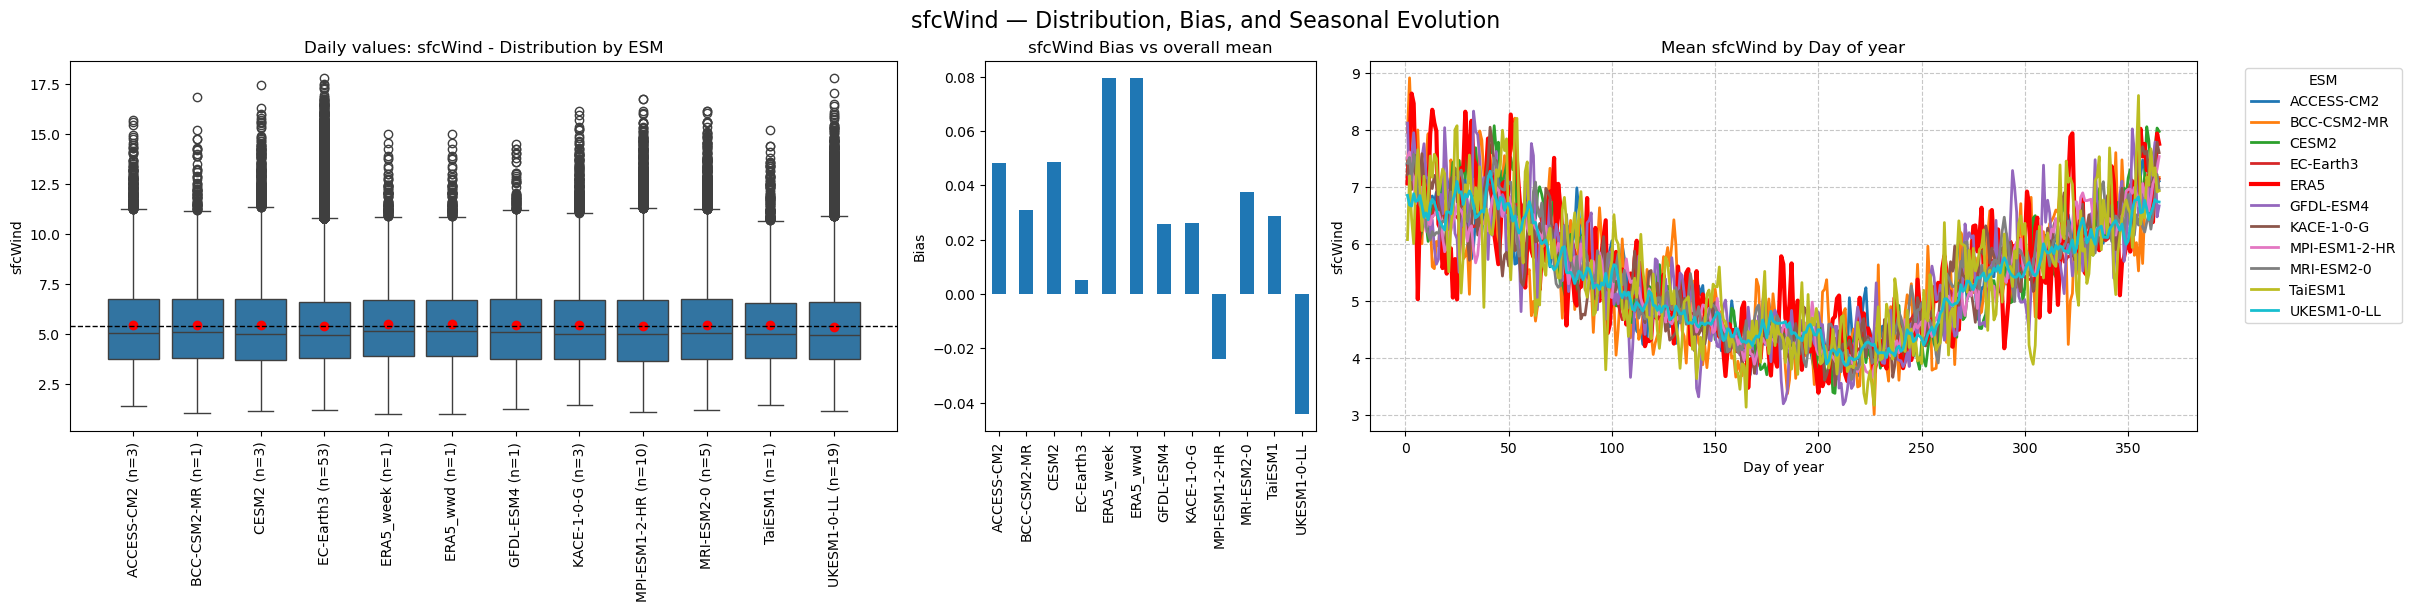

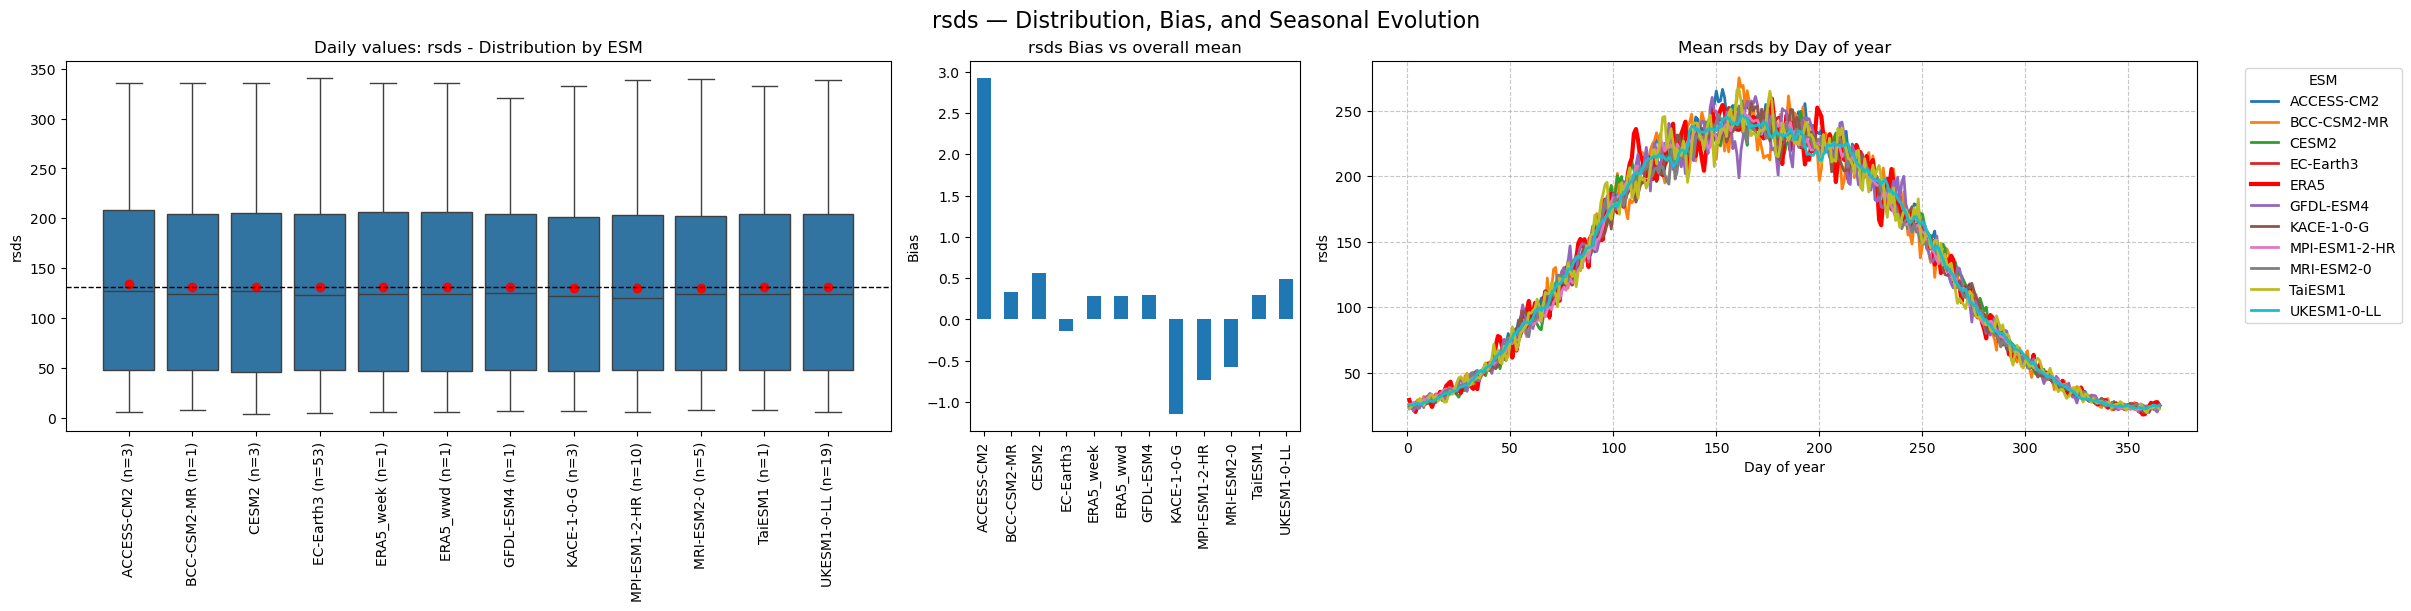

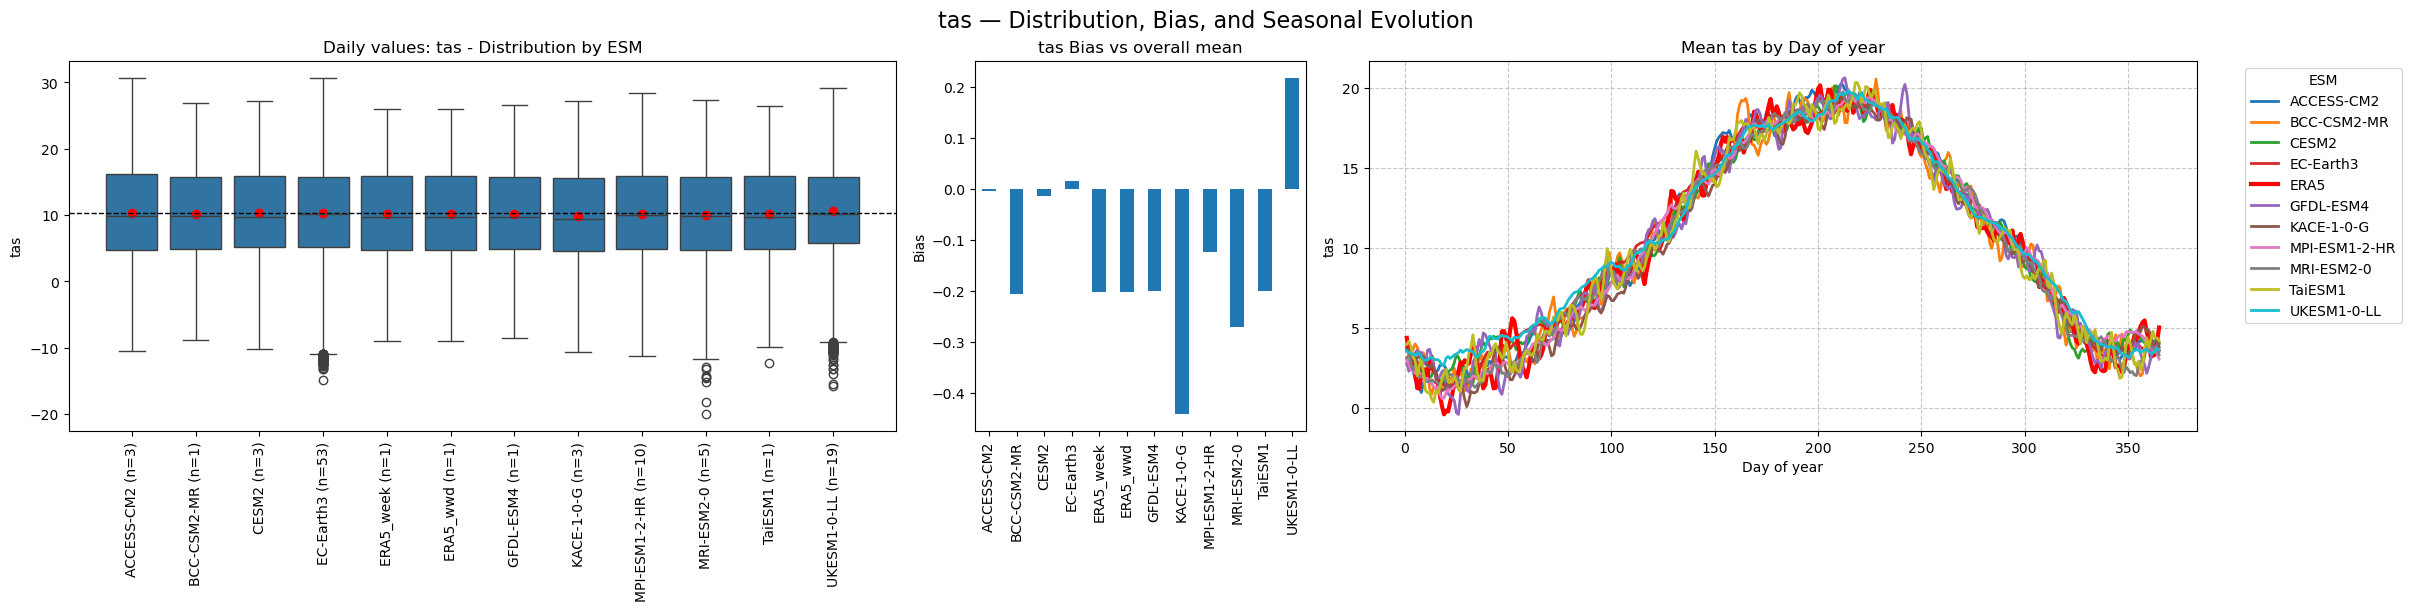

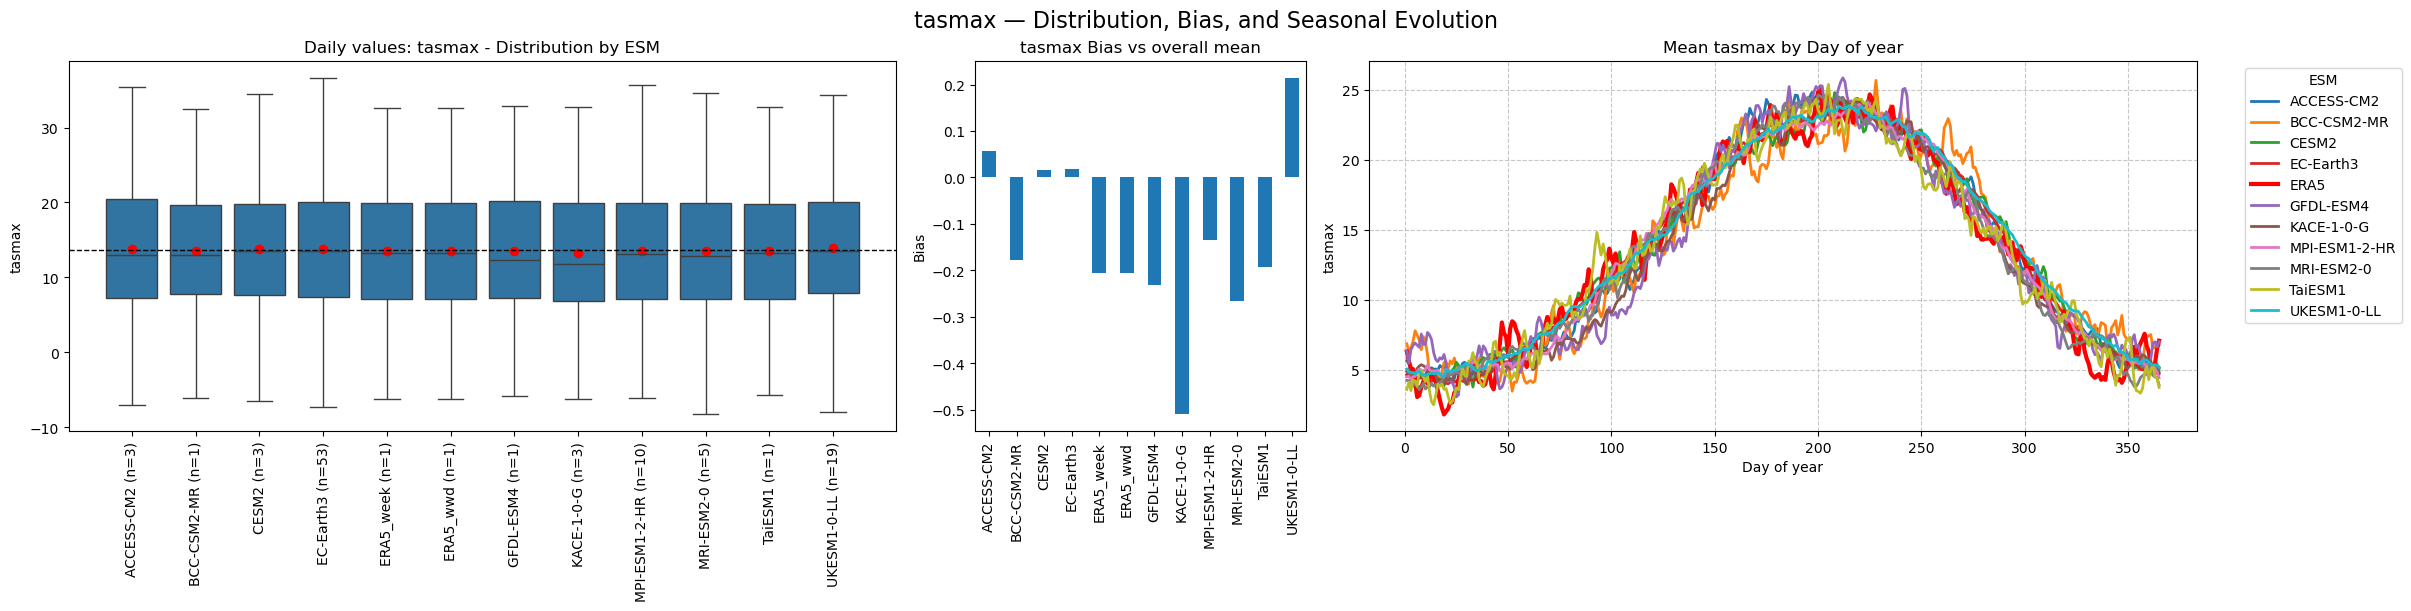

In [58]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    means = df.groupby('ESM_label')[var].mean()
    # Add mean as a line
    axes[0].plot(means.index, means.values, color='red', marker='o', linestyle='', label='Mean')
    axes[0].axhline(y=ts_datasets[var].mean('time').mean(), color='black', linestyle='--', linewidth=1)

    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5_week':
            # if esm == 'ERA5':
                axes[2].plot(group['doy'], group[var], color='red', linewidth=3, label='ERA5')
            elif esm == 'ERA5_wwd':
                continue
            else:
                axes[2].plot(group['doy'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of year')
        axes[2].set_xlabel('Day of year')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


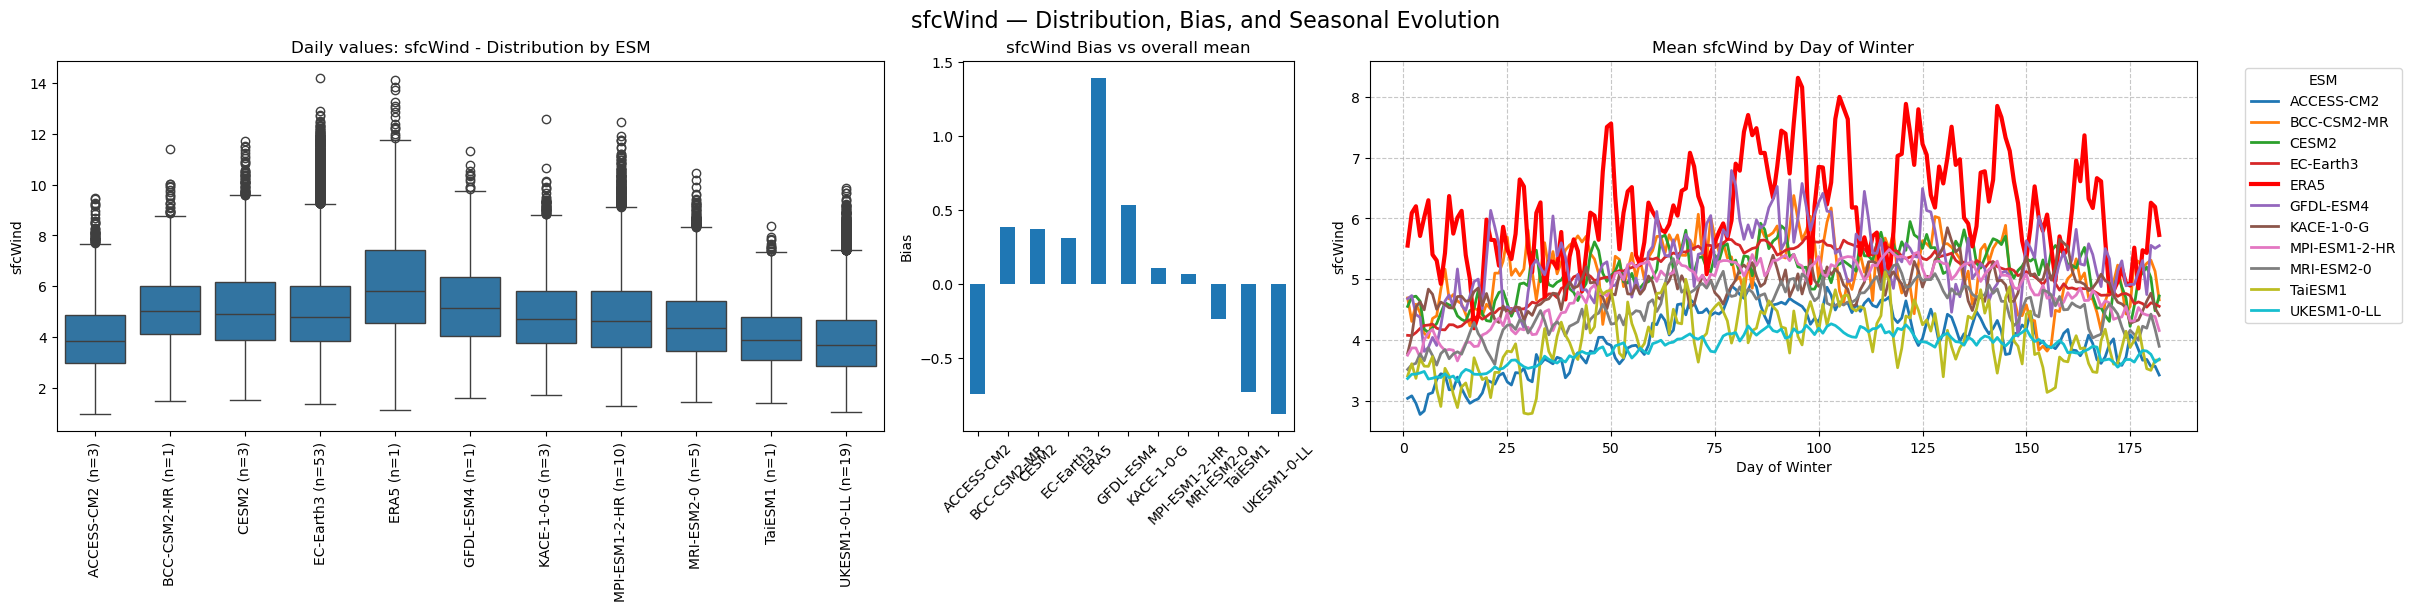

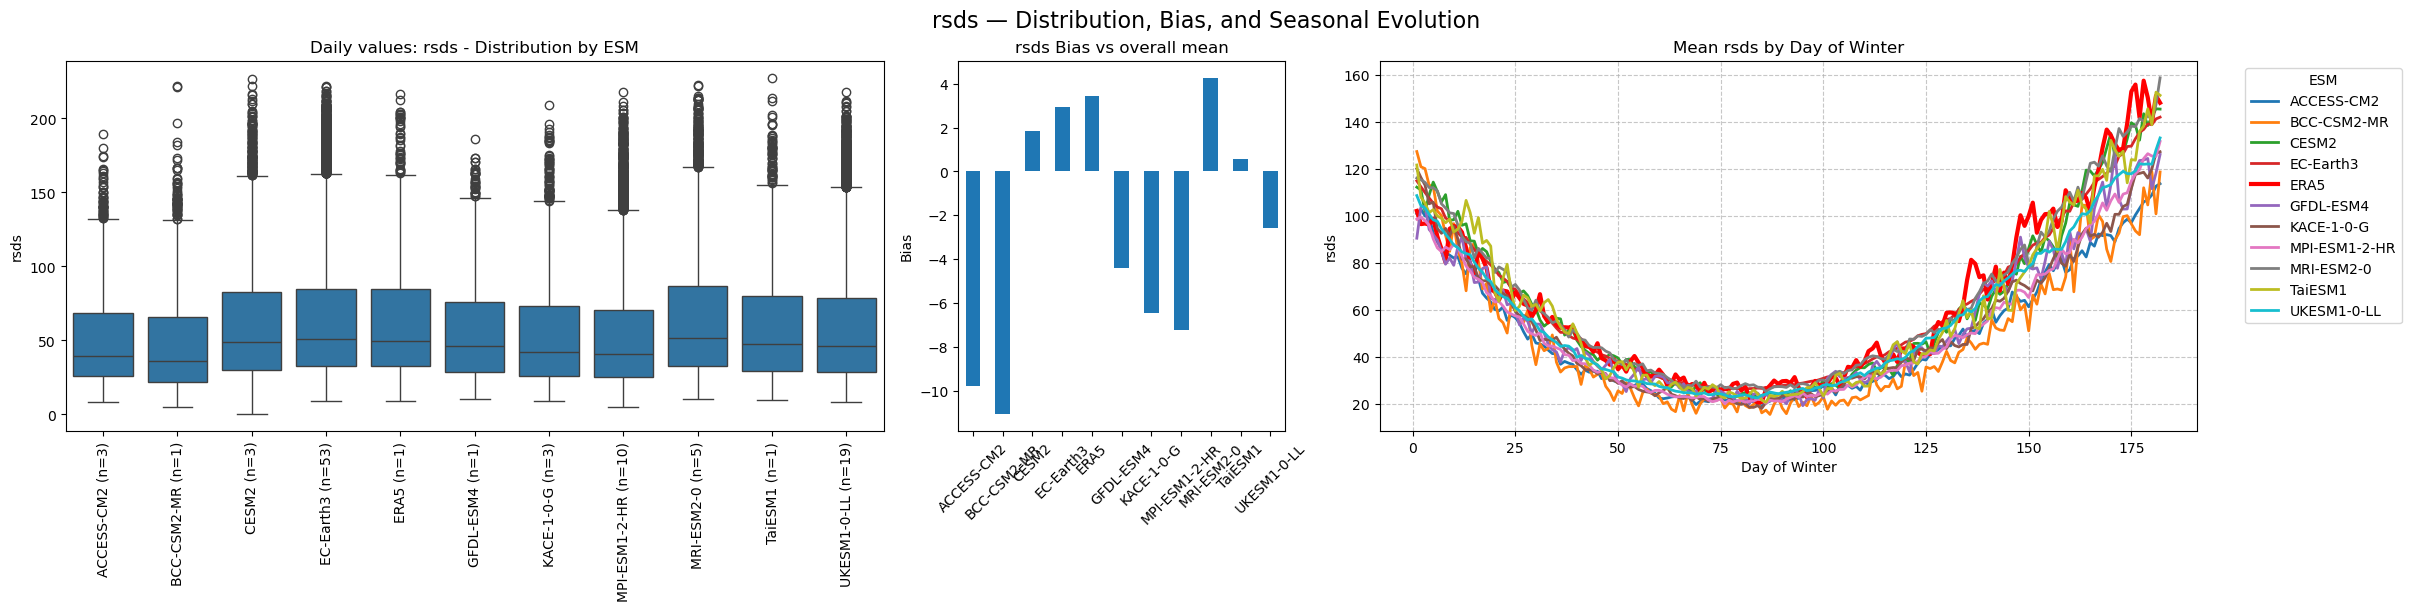

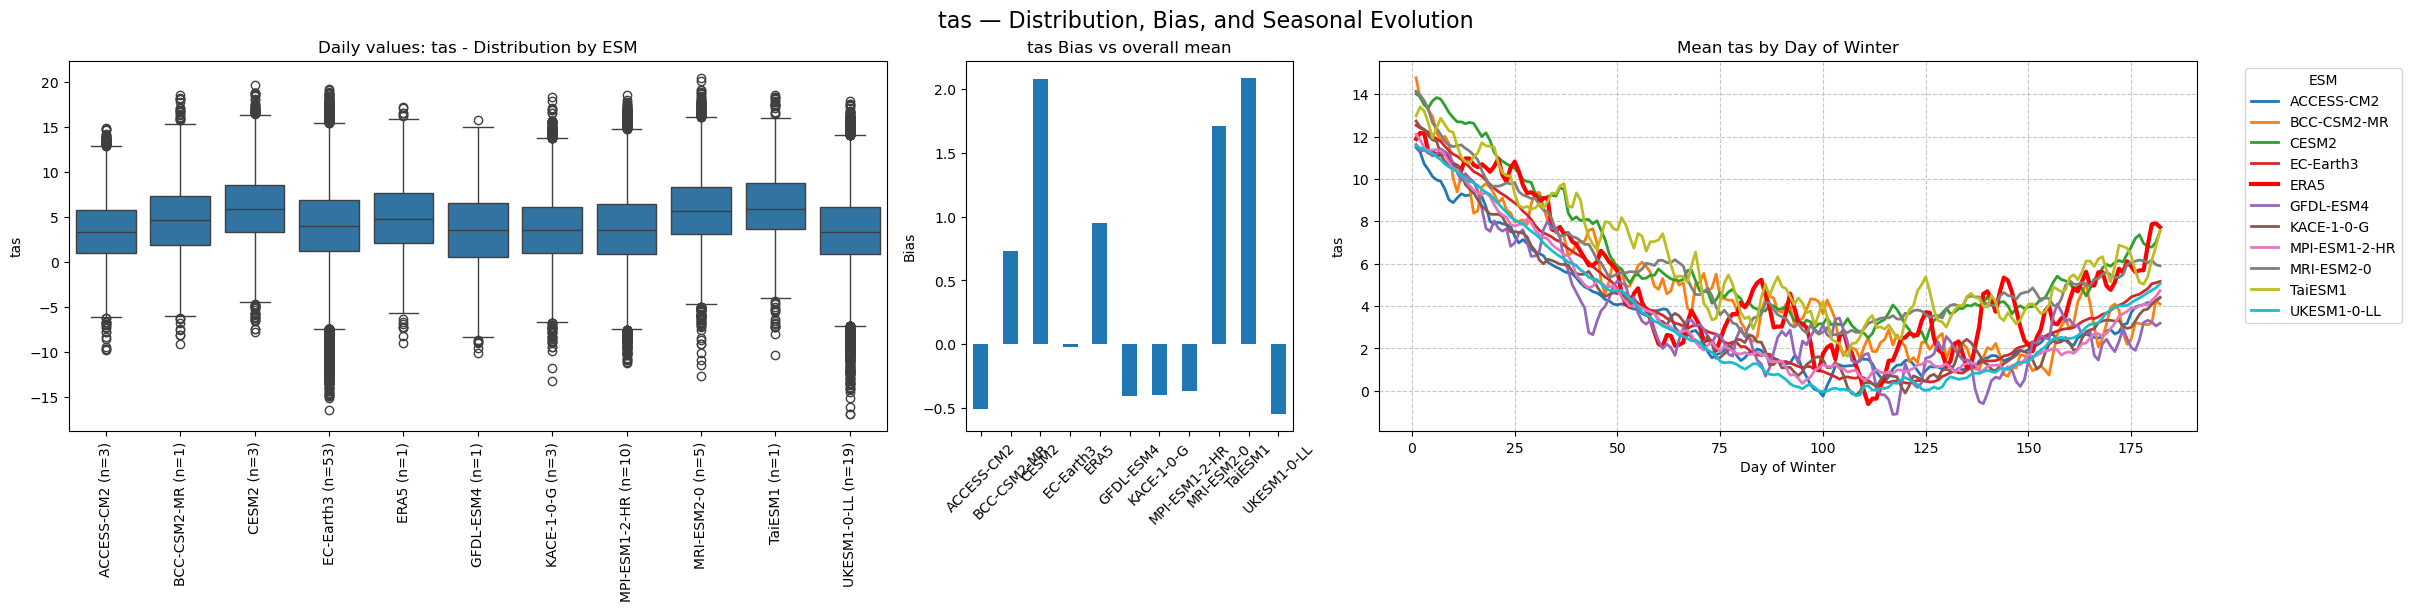

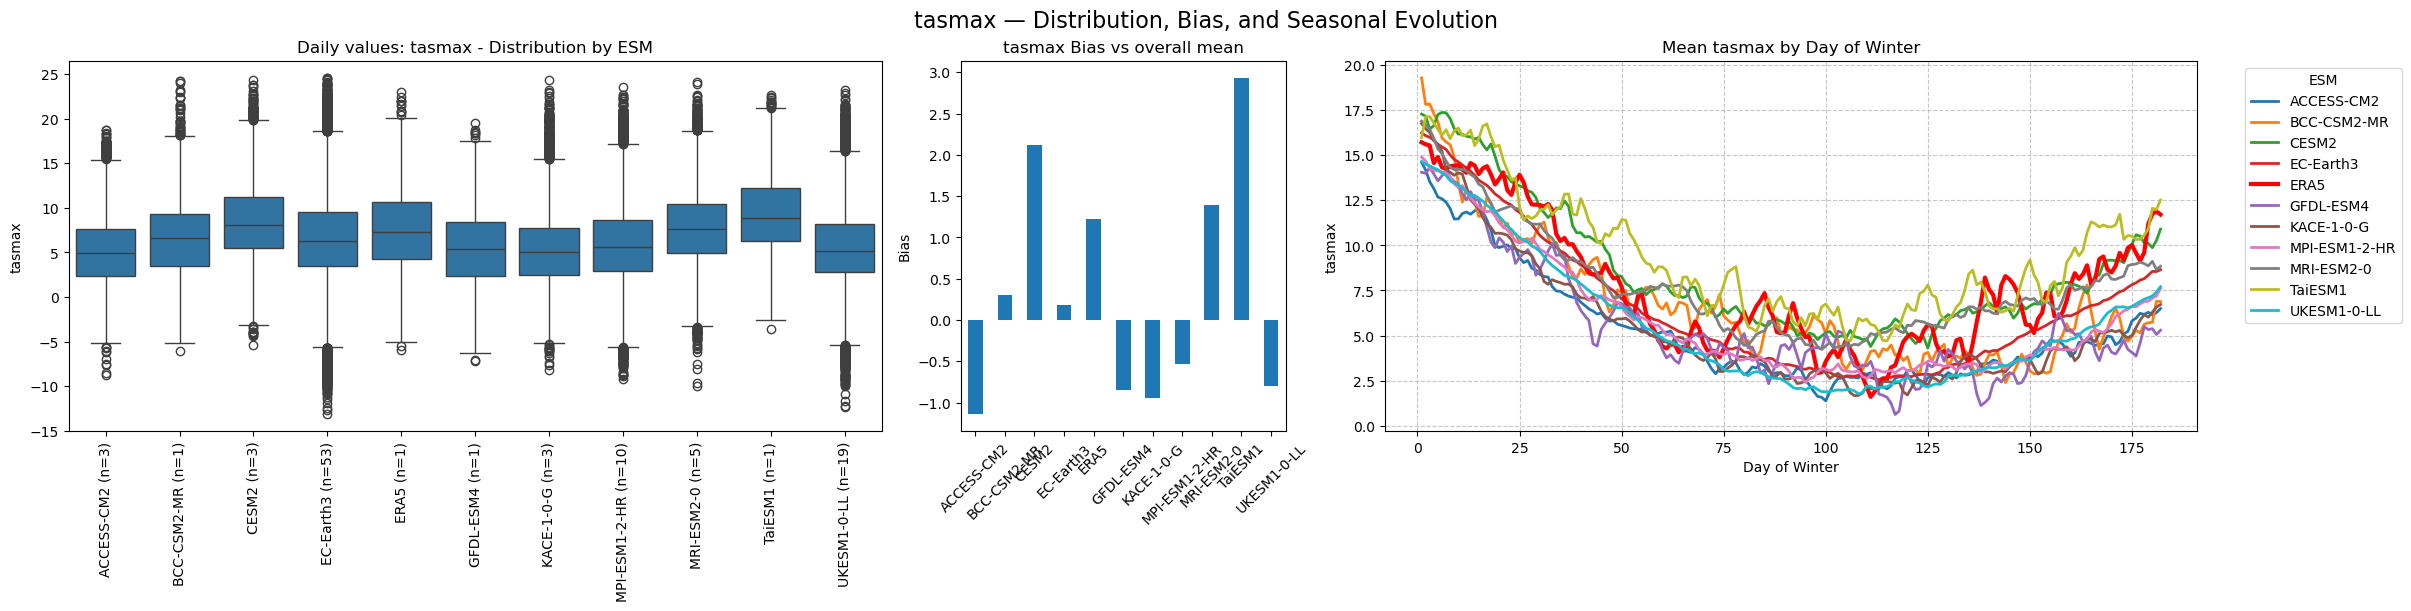

In [36]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


-----

#### Plots to look at masked mean values

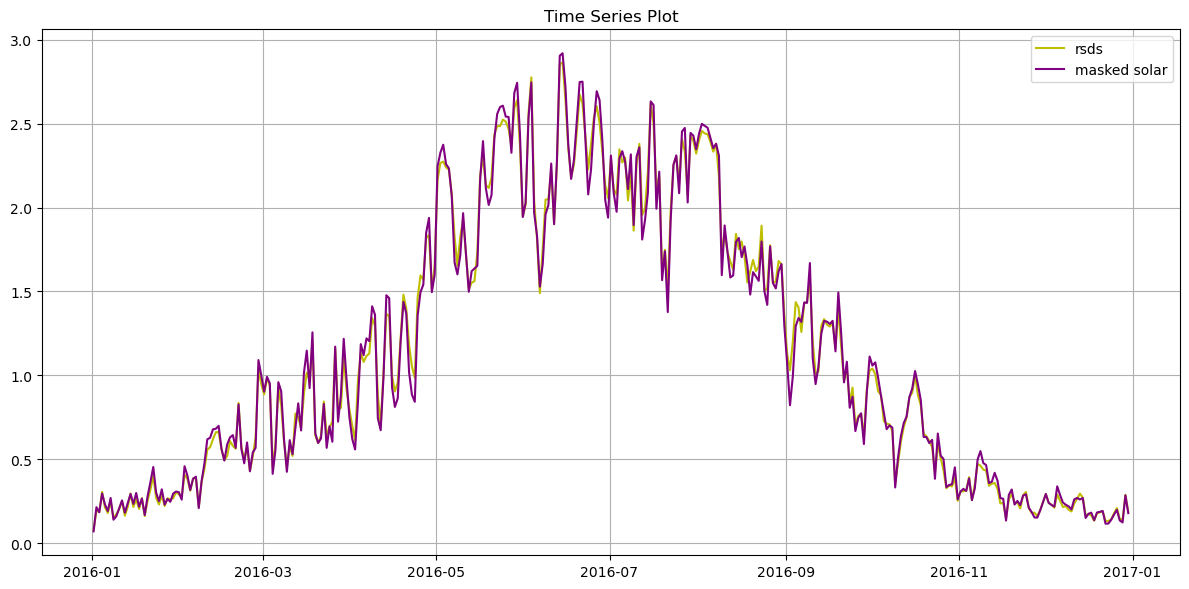

In [46]:
# Define your slice (adjust these to your desired time range)
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = ts_output['time'][a:b]
rsds = ts_output['rsds'][a:b] / 110
solar = ts_output['solar'][a:b] / 66

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, rsds, label='rsds', color='y')
ax.plot(time, solar, label='masked solar', color='purple')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

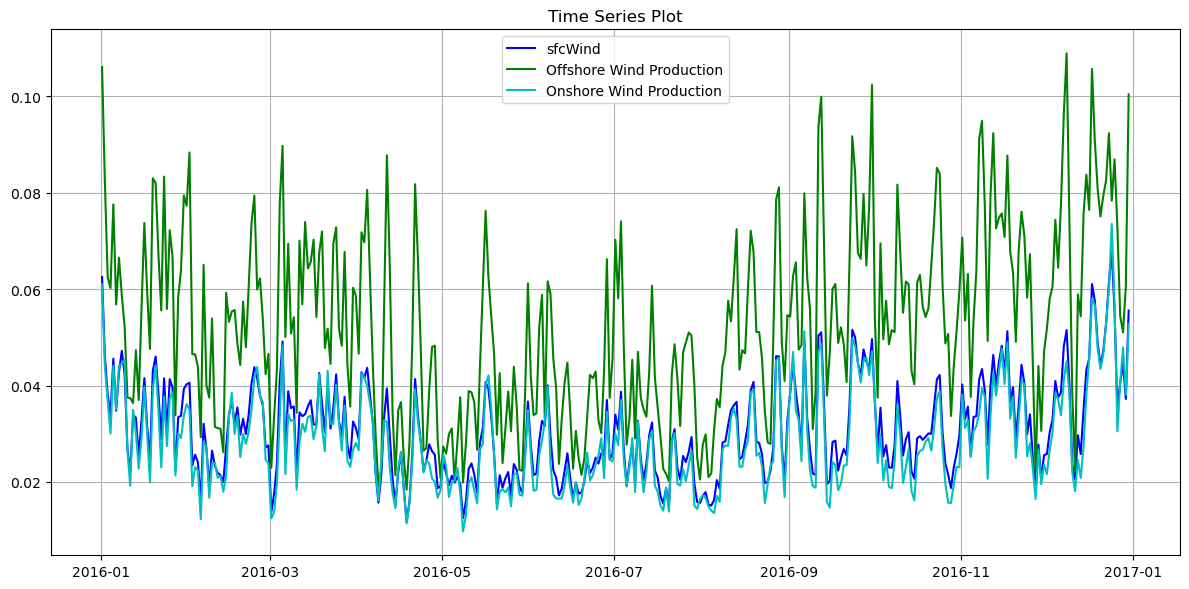

In [47]:
# Define your slice (adjust these to your desired time range)
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = ts_output['time'][a:b]
sfcWind = ts_output['sfcWind'][a:b] / 110
wind_offshore = ts_output['wind_offshore'][a:b] / 9
wind_onshore = ts_output['wind_onshore'][a:b] / 63

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, sfcWind, label='sfcWind', color='b')
ax.plot(time, wind_offshore, label='Offshore Wind Production', color='g')
ax.plot(time, wind_onshore, label='Onshore Wind Production', color='c')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()